## 7.1 Load Feature-Engineered Dataset

The feature-engineered dataset created in the previous stages is loaded for machine-learning model development.

Only the variables required for forecasting are retained to reduce memory usage and improve computational efficiency.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "outputs/tables/forecasting_features.csv"

print("Loading feature-engineered dataset...")

Loading feature-engineered dataset...


## 7.2 Select Forecasting Series

The XGBoost model uses the same representative store-product family selected during the SARIMAX stage.

Using the same series ensures that model performance can be compared consistently across forecasting approaches.

In [5]:
selected_store = 45
selected_family = "GROCERY I"

In [6]:
selected_parts = []

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=required_columns,
    chunksize=200_000
):
    selected = chunk[
        (chunk["store_nbr"] == selected_store) &
        (chunk["family"] == selected_family)
    ].copy()

    if not selected.empty:
        selected_parts.append(selected)

xgb_data = pd.concat(
    selected_parts,
    ignore_index=True
)

xgb_data["date"] = pd.to_datetime(xgb_data["date"])

xgb_data = (
    xgb_data
    .sort_values("date")
    .drop_duplicates("date")
    .reset_index(drop=True)
)

print(f"Dataset shape: {xgb_data.shape}")

Dataset shape: (1656, 6)


In [7]:
xgb_data.head()

,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-29,45,GROCERY I,"4,826.00",0,97.62
1,2013-01-30,45,GROCERY I,"5,247.00",0,97.98
2,2013-01-31,45,GROCERY I,"4,545.00",0,97.65
3,2013-02-01,45,GROCERY I,"7,136.00",0,97.46
4,2013-02-02,45,GROCERY I,"10,672.00",0,NaN


## 7.2 Machine-Learning Feature Construction

Tree-based forecasting models cannot directly understand temporal order.

Lagged demand, rolling statistics, calendar variables, and external signals are therefore transformed into numerical predictors.

These features allow XGBoost to learn relationships between recent demand behaviour and future sales.

In [8]:
df_xgb = xgb_data.copy()

df_xgb["day_of_week"] = df_xgb["date"].dt.dayofweek
df_xgb["day_of_month"] = df_xgb["date"].dt.day
df_xgb["month"] = df_xgb["date"].dt.month
df_xgb["quarter"] = df_xgb["date"].dt.quarter
df_xgb["year"] = df_xgb["date"].dt.year
df_xgb["week_of_year"] = df_xgb["date"].dt.isocalendar().week.astype(int)

df_xgb["is_weekend"] = (
    df_xgb["day_of_week"] >= 5
).astype(int)

In [9]:
lag_periods = [
    1,
    7,
    14,
    21,
    28
]

for lag in lag_periods:
    df_xgb[f"sales_lag_{lag}"] = (
        df_xgb["sales"].shift(lag)
    )

## 7.3 Rolling Demand Features

Rolling statistics summarize recent demand behaviour and provide the model with information about local demand levels and volatility.

In [10]:
df_xgb["sales_rolling_mean_7"] = (
    df_xgb["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

df_xgb["sales_rolling_mean_14"] = (
    df_xgb["sales"]
    .shift(1)
    .rolling(14)
    .mean()
)

df_xgb["sales_rolling_mean_28"] = (
    df_xgb["sales"]
    .shift(1)
    .rolling(28)
    .mean()
)

df_xgb["sales_rolling_std_7"] = (
    df_xgb["sales"]
    .shift(1)
    .rolling(7)
    .std()
)

In [11]:
df_xgb = df_xgb.dropna().reset_index(drop=True)

print(f"Final modelling dataset: {df_xgb.shape}")

Final modelling dataset: (1126, 22)


In [12]:
df_xgb.head()

,date,store_nbr,family,sales,onpromotion,dcoilwtico,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28,sales_rolling_mean_7,sales_rolling_mean_14,sales_rolling_mean_28,sales_rolling_std_7
0,2013-02-26,45,GROCERY I,"4,439.00",0,92.63,1,26,2,1,2013,9,0,"5,220.00","5,282.00","7,498.00","6,012.00","4,826.00","6,619.86","7,079.07","7,172.82","2,587.31"
1,2013-02-27,45,GROCERY I,"5,594.00",0,92.84,2,27,2,1,2013,9,0,"4,439.00","5,810.00","6,077.00","6,259.00","5,247.00","6,499.43","6,860.57","7,159.00","2,677.99"
2,2013-02-28,45,GROCERY I,"4,960.00",0,92.03,3,28,2,1,2013,9,0,"5,594.00","4,335.00","5,220.00","4,630.00","4,545.00","6,468.57","6,826.07","7,171.39","2,688.48"
3,2013-03-01,45,GROCERY I,"7,456.00",0,90.71,4,1,3,1,2013,9,0,"4,960.00","5,530.00","6,394.00","14,058.00","7,136.00","6,557.86","6,807.50","7,186.21","2,615.20"
4,2013-03-04,45,GROCERY I,"7,797.00",0,90.13,0,4,3,1,2013,10,0,"14,034.00","5,220.00","7,371.00","6,564.00","7,552.00","7,731.86","7,329.50","7,363.04","3,898.24"


## 7.4 Feature and Target Definition

Sales is defined as the prediction target.

The predictor set consists of temporal variables, lagged demand, rolling statistics, promotional activity, and external factors.

In [13]:
target = "sales"

feature_columns = [
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_21",
    "sales_lag_28",
    "sales_rolling_mean_7",
    "sales_rolling_mean_14",
    "sales_rolling_mean_28",
    "sales_rolling_std_7",
    "onpromotion",
    "dcoilwtico"
]

feature_columns = [
    col for col in feature_columns
    if col in df_xgb.columns
]

print("Number of features:", len(feature_columns))
print("\nFeatures:")
print(feature_columns)

Number of features: 18

Features:
['day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'week_of_year', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_14', 'sales_rolling_mean_28', 'sales_rolling_std_7', 'onpromotion', 'dcoilwtico']


In [14]:
TEST_DAYS = 30

xgb_train = df_xgb.iloc[:-TEST_DAYS].copy()
xgb_test = df_xgb.iloc[-TEST_DAYS:].copy()

X_train = xgb_train[feature_columns]
y_train = xgb_train[target]

X_test = xgb_test[feature_columns]
y_test = xgb_test[target]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 1096
Testing observations: 30


## 7.5 XGBoost Model

An XGBoost regression model is trained using the engineered demand, temporal, promotional, and external features.

A chronological train-test split is maintained to prevent future information from influencing model training.

In [15]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model training completed.")

XGBoost model training completed.


In [16]:
xgb_predictions = xgb_model.predict(X_test)

xgb_predictions = np.maximum(
    xgb_predictions,
    0
)

print("Forecast generated successfully.")

Forecast generated successfully.


## 7.6 XGBoost Forecast Evaluation

The XGBoost model is evaluated on the same 30-day holdout period used for the previous forecasting approaches.

MAE, RMSE, and MAPE are calculated to quantify forecast accuracy.

In [17]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

non_zero = y_test != 0

xgb_mape = (
    np.mean(
        np.abs(
            (y_test[non_zero] - xgb_predictions[non_zero])
            / y_test[non_zero]
        )
    ) * 100
)

print(f"XGBoost MAE: {xgb_mae:,.2f}")
print(f"XGBoost RMSE: {xgb_rmse:,.2f}")
print(f"XGBoost MAPE: {xgb_mape:.2f}%")

XGBoost MAE: 641.55
XGBoost RMSE: 780.44
XGBoost MAPE: 6.57%


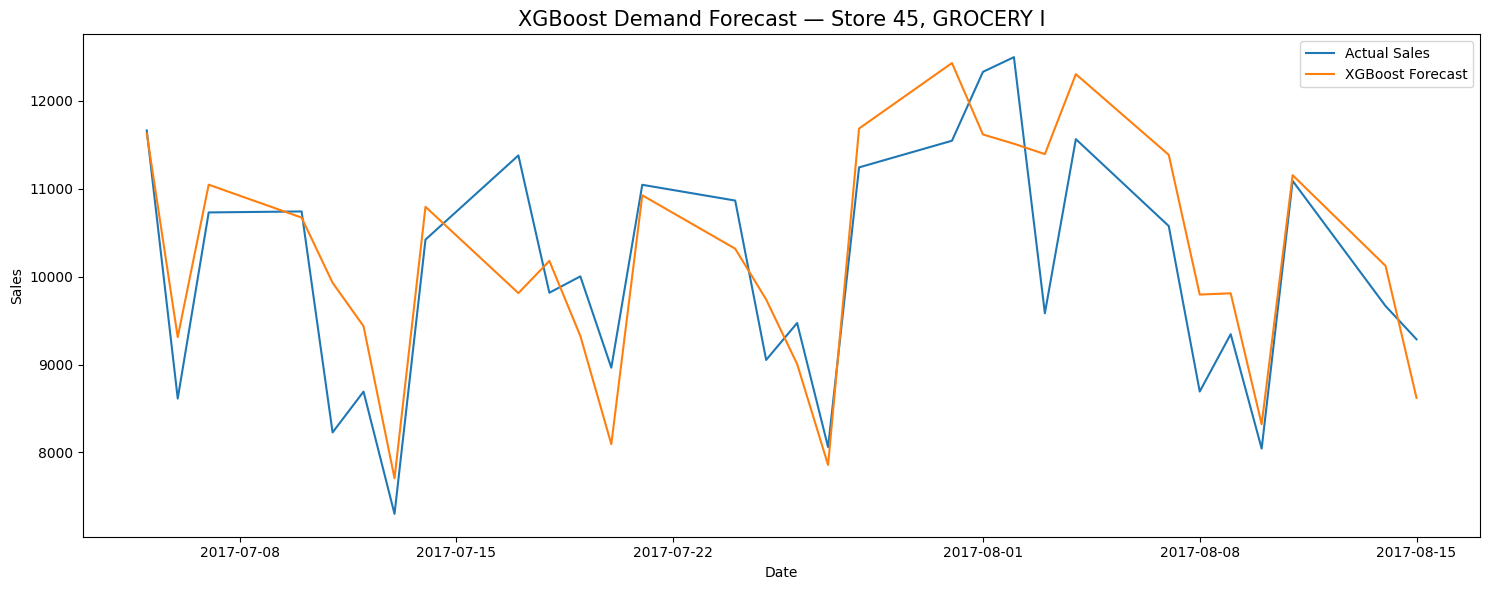

In [18]:
plt.figure(figsize=(15, 6))

plt.plot(
    xgb_test["date"],
    y_test,
    label="Actual Sales"
)

plt.plot(
    xgb_test["date"],
    xgb_predictions,
    label="XGBoost Forecast"
)

plt.title(
    f"XGBoost Demand Forecast — Store {selected_store}, {selected_family}",
    fontsize=15
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()
plt.show()

## 7.7 Feature Importance

Feature importance is examined to identify which variables contribute most strongly to the XGBoost predictions.

This provides insight into the demand drivers learned by the machine-learning model.

In [19]:
importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance": xgb_model.feature_importances_
    })
    .sort_values(
        "importance",
        ascending=False
    )
)

importance

,feature,importance
12,sales_rolling_mean_7,0.13
7,sales_lag_1,0.12
16,onpromotion,0.11
5,week_of_year,0.09
13,sales_rolling_mean_14,0.08
1,day_of_month,0.07
14,sales_rolling_mean_28,0.06
10,sales_lag_21,0.05
8,sales_lag_7,0.05
9,sales_lag_14,0.04


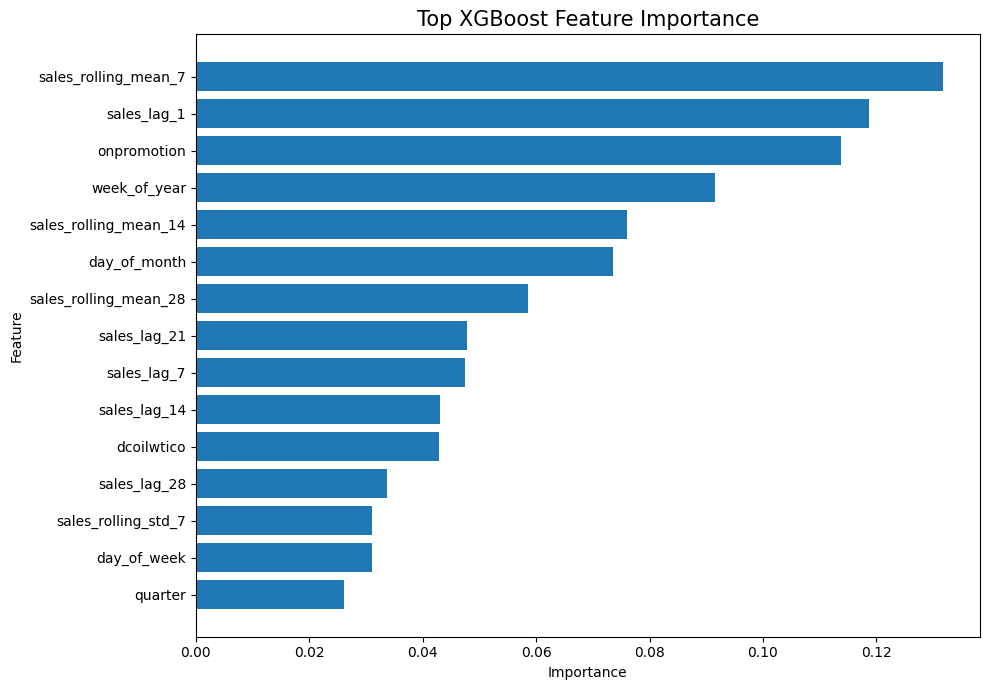

In [20]:
top_features = importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title(
    "Top XGBoost Feature Importance",
    fontsize=15
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [21]:
os.makedirs(
    "outputs/tables",
    exist_ok=True
)

xgb_results = pd.DataFrame([
    {
        "Model": "XGBoost",
        "MAE": xgb_mae,
        "RMSE": xgb_rmse,
        "MAPE": xgb_mape
    }
])

xgb_results.to_csv(
    "outputs/tables/xgboost_results.csv",
    index=False
)

xgb_forecast_output = pd.DataFrame({
    "date": xgb_test["date"],
    "actual_sales": y_test.values,
    "xgboost_forecast": xgb_predictions
})

xgb_forecast_output.to_csv(
    "outputs/tables/xgboost_forecast.csv",
    index=False
)

importance.to_csv(
    "outputs/tables/xgboost_feature_importance.csv",
    index=False
)

print("XGBoost outputs exported successfully.")

XGBoost outputs exported successfully.


## 7.8 Forecasting Model Comparison

The forecasting approaches developed throughout the project are compared using a common out-of-sample evaluation period.

The comparison includes a seasonal naive benchmark, SARIMAX, and XGBoost.

This evaluation determines whether increasing model complexity provides a measurable improvement in forecasting accuracy.

In [24]:
sarimax_results = pd.read_csv(
    "outputs/tables/sarimax_results.csv"
)

xgb_results = pd.read_csv(
    "outputs/tables/xgboost_results.csv"
)

sarimax_results

,Model,MAE,RMSE
0,Seasonal Naive,"1,357.77","1,744.01"
1,SARIMAX,"1,889.02","2,420.27"


In [25]:
xgb_results

,Model,MAE,RMSE,MAPE
0,XGBoost,641.55,780.44,6.57


In [26]:
baseline_row = sarimax_results[
    sarimax_results["Model"] == "Seasonal Naive"
].iloc[0]

sarimax_row = sarimax_results[
    sarimax_results["Model"] == "SARIMAX"
].iloc[0]

xgb_row = xgb_results[
    xgb_results["Model"] == "XGBoost"
].iloc[0]

In [27]:
model_comparison = pd.DataFrame([
    {
        "Model": "Seasonal Naive",
        "MAE": baseline_row["MAE"],
        "RMSE": baseline_row["RMSE"]
    },
    {
        "Model": "SARIMAX",
        "MAE": sarimax_row["MAE"],
        "RMSE": sarimax_row["RMSE"]
    },
    {
        "Model": "XGBoost",
        "MAE": xgb_row["MAE"],
        "RMSE": xgb_row["RMSE"]
    }
])

model_comparison

,Model,MAE,RMSE
0,Seasonal Naive,"1,357.77","1,744.01"
1,SARIMAX,"1,889.02","2,420.27"
2,XGBoost,641.55,780.44


In [28]:
best_model = model_comparison.loc[
    model_comparison["MAE"].idxmin(),
    "Model"
]

best_mae = model_comparison["MAE"].min()

print(f"Best-performing model: {best_model}")
print(f"Lowest MAE: {best_mae:,.2f}")

Best-performing model: XGBoost
Lowest MAE: 641.55


In [29]:
baseline_mae = baseline_row["MAE"]
sarimax_mae = sarimax_row["MAE"]
xgb_mae = xgb_row["MAE"]

sarimax_improvement = (
    (baseline_mae - sarimax_mae)
    / baseline_mae
) * 100

xgb_improvement = (
    (baseline_mae - xgb_mae)
    / baseline_mae
) * 100

print(
    f"SARIMAX improvement over Seasonal Naive: "
    f"{sarimax_improvement:.2f}%"
)

print(
    f"XGBoost improvement over Seasonal Naive: "
    f"{xgb_improvement:.2f}%"
)

SARIMAX improvement over Seasonal Naive: -39.13%
XGBoost improvement over Seasonal Naive: 52.75%
